In [1]:
import spacy
import en_core_web_lg
import pandas as pd
import numpy as np
import nltk
import plotly.express as px
import matplotlib.pyplot as plt
from textblob import TextBlob
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Flatten, LSTM, Dropout, Activation, Embedding
nltk.download('vader_lexicon')
import panel as pn
import warnings; warnings.filterwarnings('ignore')

def show_panel(df,top=20):
    return pn.widgets.Tabulator(df.head(top),
                    show_index=False,
                    pagination='local', 
                         page_size=10)
        
pn.extension('tabulator')
pn.widgets.Tabulator.theme = 'bootstrap'

/opt/conda/lib/python3.7/site-packages/nltk/twitter/__init__.py:20: UserWarning: The twython library has not been installed. Some functionality from the twitter package will not be available.
  warnings.warn("The twython library has not been installed. "


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


![](https://i.imgur.com/1I7DFNO.jpg)

# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;background-color:#FFFFFF;overflow:hidden;background-color:#CDE10F"><b><span style='color:#FFFFFF'>1 |</span></b> <b>INTRODUCTION</b></div>

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>NATURAL LANGUAGE PROCESSING</span></b></p></div>

- Natural Language Processing (NLP) is a subfield of artificial intelligence (AI) that focuses on the interaction between computers and humans using natural language
- It involves the use of algorithms and computational techniques to analyze, understand, and generate human language in a way that is meaningful to both machines and humans
- NLP is used in a variety of applications such as chatbots, voice assistants, sentiment analysis, machine translation, and text summarization
- Its ultimate goal is to enable machines to understand and interpret human language as accurately as possible

<br>

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>STOCK PRICE INFLUENCE</span></b></p></div>

Features that can be useful for **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">stock price</mark>** prediction as outlined by <b>Tatsat et al (2020)</b>

##### **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">CORRELATED ASSETS</mark>**

An organization depends on and interacts with many external factors, including its competitors, clients, the global economy, the geopolitical situation, fiscal and monetary policies, access to capital, and so on. Hence, its stock price may be correlated not only with the stock price of other companies but also with other assets such as commodities, FX, broad-based indices, or even fixed income securities.

##### **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">TECHNICAL INDICATORS</mark>**

A lot of investors follow technical indicators. Moving average, exponential moving average, and momentum are the most popular indicators

##### **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">TECHNICAL REPORTS</mark>**

Annual and quarterly reports of companies can be used to extract or determine key metrics, such as ROE (Return on Equity) and P/E (Price-toEarnings).

##### **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">NEWS REPORTS</mark>**

News can indicate upcoming events that can potentially move the stock price in a certain direction.

In another **[notebook](https://www.kaggle.com/code/shtrausslearning/building-an-asset-trading-strategy)**, I mentioned **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">technical indicators</mark>**, lets look at **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">news reports</mark>** in this notebook

<br>

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>NATURAL LANGUAGE AIMDED TRADING STRATEGY</span></b></p></div>

- Using NLP, we can ask ourselves questions such as, how positive or negative a news article (related to financial markets is)
- NLP provides a way to monitor **financial market** **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">sentiments</mark>** by utilising any text based source (eg. news articles, reports, social media, expert opinions) 
- So we can determine whether the text based source, posted on specific day, has a positive or negative sentiment score 
- By combining **historic market data** with **news sources related to financial markets**, we can create a **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">trading strategy</mark>** that utilises NLP

<br>

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>STUDY AIM</span></b></p></div>


- The goal of this study is to build a trading strategy that uses NLP to extract information from the news headlines
- Assign a sentiment to the news headline, and use the sentiments and a trading strategy

<br>

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>DATA SOURCES</span></b></p></div>

- Yahoo Finance Stock Data **[yfinance](https://pypi.org/project/yfinance/)**
- Parsed news headline data from RSS feeds 
- Expert labelled headline data from **[Github](https://raw.githubusercontent.com/tatsath/fin-ml/master/Chapter%2010%20-%20Natural%20Language%20Processing/Case%20Study%201%20-%20NLP%20and%20Sentiments%20Analysis%20based%20Trading%20Strategy/Data/LabelledNewsData.csv)**


# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;background-color:#FFFFFF;overflow:hidden;background-color:#CDE10F"><b><span style='color:#FFFFFF'>2 |</span></b> <b>LOADING DATA</b></div>

We will be combining two sources of data based on the `Data` index, we will need **closing financial market** data, as well as **news headline** data during the period from 2010 to 2018, from these two pieces of information, we'll attempt to create a trading strategy

Let's summarise what we'll be doing:

- We will need to parse the RSS headline data (which is stored in JSON)
- We will need to load the stock market data for the selected stocks
- We will need to decide on an event return value (should we use just the difference in closing values?)
- We will need to merge the two data sources (which we will do on both ticker & date)


<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>LOADING STOCK PRICE HISTORY</span></b></p></div>

Let's select **12 stock tick data** for the period **2010 to 2018** from `yfinance`
- `AAPL`, `MSFT`, `AMZN`, `GOOG`, `AMD`, `NVDA`, `TSLA`, `YELP`, `NFLX`, `ADBE`, `BA` & `AIG`

In [2]:
!pip install yfinance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.8/109.8 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 68.6 MB/s eta 0:00:00
  Installing build dependencies ... - \ | / done
  Getting requirements to build wheel ... - done
  Preparing metadata (pyproject.toml) ... - done
  Created wheel for peewee: filename=peewee-3.17.9-py3-none-any.whl size=138997 sha256=3863ead1d0dbb12535e120b12a3e50aa0e1f05967ce4688b1c8f01c70cfe152a
  Stored in directory: /root/.cache/pip/wheels/a7/3b/2f/38b1faafe93ff93f87cfacaa377e82c27b8b81d0ce63a76063
Successfully built peewee
  Attempting uninstall: requests
    Found existing installation: requests 2.28.2
    Uninstalling requests-2.28.2:
      Successfully uninstalled requests-2.28.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following 

In [3]:
import yfinance as yf

tickers = ['AAPL','MSFT','AMZN','GOOG',
           'AMD','NVDA','TSLA','YELP',
           'NFLX','ADBE','BA','AIG']

start = '2010-01-01'
end = '2018-12-31'
df_ticker_return = pd.DataFrame()
for ticker in tickers:    
    ticker_yf = yf.Ticker(ticker)
    if df_ticker_return.empty:
        df_ticker_return = ticker_yf.history(start = start, end = end)
        df_ticker_return['ticker']= ticker 
    else:
        data_temp = ticker_yf.history(start = start, end = end)
        data_temp['ticker']= ticker 
        df_ticker_return = df_ticker_return.append(data_temp)

df_ticker_return['ticker'] = df_ticker_return['ticker'].replace({'META':'FB'})
print(df_ticker_return['ticker'].unique())
df_ticker_return.to_csv(r'return_data.csv')

['AAPL' 'MSFT' 'AMZN' 'GOOG' 'AMD' 'NVDA' 'TSLA' 'YELP' 'NFLX' 'ADBE' 'BA'
 'AIG']


<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>LOADING STOCK PRICE HISTORY</span></b></p></div>

Load the data from a dataset `return_data` dataframe, here it is loaded locally

In [4]:
# We can preread the data
df_ticker_return = pd.read_csv('return_data.csv',
                               index_col='Date')
df_ticker_return.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker
Date,,,,,,,,
2010-01-04 00:00:00-05:00,6.422876,6.455076,6.391278,6.440331,493729600,0.0,0.0,AAPL
2010-01-05 00:00:00-05:00,6.458085,6.487878,6.417459,6.451465,601904800,0.0,0.0,AAPL
2010-01-06 00:00:00-05:00,6.451464,6.477044,6.342224,6.348845,552160000,0.0,0.0,AAPL
2010-01-07 00:00:00-05:00,6.372319,6.379843,6.291066,6.337109,477131200,0.0,0.0,AAPL
2010-01-08 00:00:00-05:00,6.328685,6.379844,6.291369,6.379242,447610800,0.0,0.0,AAPL


Check all unique tickers & plot the `close` price of all stocks mentioned earlier

In [5]:
tickers = list(df_ticker_return['ticker'].unique())
print(tickers)

['AAPL', 'MSFT', 'AMZN', 'GOOG', 'AMD', 'NVDA', 'TSLA', 'YELP', 'NFLX', 'ADBE', 'BA', 'AIG']


In [6]:
fig = px.line(df_ticker_return,y='Close',facet_col='ticker',
              facet_col_wrap=3,height=900,template='plotly_white')
fig.update_traces(line_color='#CDE10F', line_width=2)
fig.show(renderer='iframe')

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>LOADING NEWS HEADLINE DATA</span></b></p></div>

- We will be using only **headline data** obtained from RSS feeds
- The data is stored in `JSON` format and needs to be parsed so **text data** can be extracted

In [7]:
import zipfile
import json

z = zipfile.ZipFile("/kaggle/input/news-trading/headlines_archive", "r")
testFile=z.namelist()[10]
fileData= z.open(testFile).read() 
fileDataSample = json.loads(fileData)['content'][1:500]  

# json format
fileDataSample

'li class="n-box-item date-title" data-end="1305172799" data-start="1305086400" data-txt="Tuesday, December 17, 2019">Wednesday, May 11, 2011</li><li class="n-box-item sa-box-item" data-id="76179" data-ts="1305149244"><div class="media media-overflow-fix"><div class="media-left"><a class="box-ticker" href="/symbol/CSCO" target="_blank">CSCO</a></div><div class="media-body"><h4 class="media-heading"><a href="/news/76179" sasource="on_the_move_news_fidelity" target="_blank">Cisco (NASDAQ:CSCO): Pr'

In [8]:
from lxml import etree
from io import StringIO
from datetime import date
from tqdm.notebook import tqdm

# helper function performs the jsn parsing 

def jsonParser(json_data): 
    xml_data = json_data['content']
            
    tree = etree.parse(StringIO(xml_data), parser=etree.HTMLParser())

    headlines = tree.xpath("//h4[contains(@class, 'media-heading')]/a/text()")
    assert len(headlines) == json_data['count']

    main_tickers = list(map(lambda x: x.replace('/symbol/', ''), tree.xpath("//div[contains(@class, 'media-left')]//a/@href")))
    assert len(main_tickers) == json_data['count']
    final_headlines = [''.join(f.xpath('.//text()')) for f in tree.xpath("//div[contains(@class, 'media-body')]/ul/li[1]")]
    if len(final_headlines) == 0:
        final_headlines = [''.join(f.xpath('.//text()')) for f in tree.xpath("//div[contains(@class, 'media-body')]")]
        final_headlines = [f.replace(h, '').split('\xa0')[0].strip() for f,h in zip (final_headlines, headlines)]
        
    return main_tickers, final_headlines


data = None 
data_df_news = []
ret = []
ret_f = []
with zipfile.ZipFile("/kaggle/input/news-trading/headlines_archive", "r") as z:
    
    for filename in tqdm(z.namelist()): 
#         print(filename)
        try:               
            #print('Running {}'.format(filename))
            with z.open(filename) as f:  
                data = f.read()  
                json_data = json.loads(data)      
            if json_data.get('count', 0)> 10:
                
                #Step 1: Parse the News Jsons 
                main_tickers, final_headlines = jsonParser(json_data) 
                
                if len(final_headlines) != json_data['count']:
                    continue
                    
                #Step 2: Prepare Future and Event Return and assign Future and Event return for each ticker. 
                file_date = filename.split('/')[-1].replace('.json', '')
                file_date = date(int(file_date[:4]), int(file_date[5:7]), int(file_date[8:]))
                
               #Step 3: Merge all the data in a data frame
                df_dict = {'ticker': main_tickers,
                           'headline': final_headlines,            
                           'date': [file_date] * len(main_tickers)}
                
                df_f = pd.DataFrame(df_dict)                    
                data_df_news.append(df_f)
                
        except:
            pass  

data_df_news=pd.concat(data_df_news)
display(data_df_news.head())
print(data_df_news.shape)

  0%|          | 0/3159 [00:00<?, ?it/s]

,ticker,headline,date
0,DVA,Davita (NYSE:DVA): EPS of $0.96 beats by $0.01...,2011-05-02
1,CGNX,Cognex (NASDAQ:CGNX): EPS of $0.32 beats by $0...,2011-05-02
2,AEIS,Advanced Energy Industries (NASDAQ:AEIS):,2011-05-02
3,LOCM,Local.com (NASDAQ:LOCM):,2011-05-02
4,CYDEQ,CyberDefender (CYDE):,2011-05-02


(122613, 3)


In [9]:
# select all tickers except for empty
data_df_news = data_df_news[~(data_df_news['ticker'] == '')]
data_df_news.shape

(110711, 3)

In [10]:
px.bar(data_df_news['ticker'].value_counts()[:100],template="plotly_white")

<div style=" background-color:#3b3745;text-align:left; padding: 13px 13px; border-radius: 8px; color: white">
    
<ul>
<li>Parsed news headline data numbers ranging from 524 to 112 for the most common 100 unique tickers</li>

</ul>
</div>

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>EVENT RETURN</span></b></p></div>

- For the target variable, we will use **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">event return</mark>**, which is the return that corresponds to an event in the market
- The event influence can come into effect before, at the time of publication and even after the event/publication of news (ie. t-1,t,t+1)
- A wider window range **[t,t+1]** is used over instantaneous t in order to ensure in this study


In [11]:
#Computing the return
df_ticker_return['ret_curr'] = df_ticker_return['Close'].pct_change()

#Computing the event return
# rtm1 = df_ticker_return['ret_curr'].shift(-1) # return a day before the news
rtp1 = df_ticker_return['ret_curr'].shift(1) # return a day after the news
rt = df_ticker_return['ret_curr'] # return the day of the news

df_ticker_return['eventRet'] =  rt + rtp1 
df_ticker_return.reset_index(level=0, inplace=True)

df_ticker_return['date'] = pd.to_datetime(df_ticker_return['Date']).apply(lambda x: x.date())

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>MERGE DATA</span></b></p></div>

Next, let's merge both of the dataframe together

In [12]:
# merge on date and ticker
df_all = pd.merge(data_df_news, df_ticker_return, 
                  how='left', 
                  left_on=['date','ticker'], 
                  right_on=['date','ticker'])

df_all = df_all[df_all['ticker'].isin(tickers)]
df_all = df_all[['ticker','headline','date','eventRet','Close']]
df_all = df_all.dropna()
df_all = df_all.reset_index(drop=True)
df_all.to_csv('combined.csv',index=False)

In [13]:
# preread combined dataframe
data_df = pd.read_csv('combined.csv')
data_df = data_df.dropna()
data_df.head()

,ticker,headline,date,eventRet,Close
0,AMZN,Whole Foods (WFMI) -5.2% following a downgrade...,2011-05-02,0.031269,10.059500
1,NFLX,Netflix (NFLX +1.1%) shares post early gains a...,2011-05-02,0.012173,33.884285
2,MSFT,The likely winners in Microsoft's (MSFT -1.4%)...,2011-05-10,-0.007741,19.805025
3,MSFT,Microsoft (MSFT -1.2%) and Skype signed their ...,2011-05-10,-0.007741,19.805025
5,AMZN,Amazon.com (AMZN -1.7%) shares slip as comment...,2011-05-12,0.010426,10.303500


In [14]:
print(data_df.shape, data_df.ticker.unique().shape)

(3142, 5) (12,)


# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;background-color:#FFFFFF;overflow:hidden;background-color:#CDE10F"><b><span style='color:#FFFFFF'>3 |</span></b> <b>SENTIMENT EVALUATION</b></div>


<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>TEXTBLOB SENTIMENT POLARITY</span></b></p></div>

We will utilise **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">textblob</mark>** library, which utilises a **Naive Bayes** model that was **pretraied on movie reviews**, so it may not be optimal for this problem, but it's a quick way for us to get the sentiments of our news headline data

Let's use the pretrained Naive Bayes model to evaluate the **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">polarity</mark>** of the corpus documents

In [15]:
data_df['sent_blob'] = data_df['headline'].apply(lambda row: TextBlob(row).sentiment.polarity)
data_df.head()

,ticker,headline,date,eventRet,Close,sent_blob
0,AMZN,Whole Foods (WFMI) -5.2% following a downgrade...,2011-05-02,0.031269,10.059500,0.262500
1,NFLX,Netflix (NFLX +1.1%) shares post early gains a...,2011-05-02,0.012173,33.884285,-0.043750
2,MSFT,The likely winners in Microsoft's (MSFT -1.4%)...,2011-05-10,-0.007741,19.805025,0.166667
3,MSFT,Microsoft (MSFT -1.2%) and Skype signed their ...,2011-05-10,-0.007741,19.805025,-0.030556
5,AMZN,Amazon.com (AMZN -1.7%) shares slip as comment...,2011-05-12,0.010426,10.303500,0.000000


<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>SENTIMENT VS EVENT RETURN</span></b></p></div>

Let's look at the relation between **sentiment polarity** and the **event return**

In [16]:
fig = px.scatter(data_df,x='sent_blob',y='eventRet',
                 facet_col='ticker',facet_col_wrap=3,
                 template='plotly_white',
                 width=None,height=1000,
                 title='event return & textblop sentiment scatter plot')
fig.update_traces(marker=dict(size=5,
                              line=dict(width=1,
                                        color='DarkSlateGrey')),
                  opacity=0.3,
                  selector=dict(mode='markers'))

fig.show(renderer='iframe')

<div style=" background-color:#3b3745;text-align:left; padding: 13px 13px; border-radius: 8px; color: white">
    
<ul>
<li>Ideally we would like the polarity to be correlated to return, which is not always the case as we can see in the above figure</li>
<li>Netflix,Tesla and Yelp & AMD have quite a spread relation, which is far from ideal, and would be one of the sources of model error

</ul>
</div>

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>SUBSET CORRELATION</span></b></p></div>

Let's evaluate the **linear correlation** of the sentiment of each label and the event return

In [17]:
ticker_dict = dict(tuple(data_df.groupby('ticker')))

lst_corrs = []; lst_keys = []
for key,value in ticker_dict.items():
    corr_val = ticker_dict[key]['sent_blob'].corr(ticker_dict[key]['eventRet'])
    lst_keys.append(key)
    lst_corrs.append(round(corr_val,3))
    
    
ddf = pd.DataFrame(zip(lst_keys,lst_corrs))
ddf.columns = ['ticker','corr']
    
fig = px.bar(ddf,x='ticker',y='corr',template='plotly_white',
             width=None,height=400,title='event & sentiment correlation')

fig.show(renderer='iframe')

<div style=" background-color:#3b3745;text-align:left; padding: 13px 13px; border-radius: 8px; color: white">
    
<ul>
<li>We can note that <b>amazon</b> and <b>adobe</b> have the lowest correlation values (as we already have seen in the figures above)</li>
<li>Despite the spread seen in the scatter plots, we can see that for <b>Tesla</b> stock, the correlation is higher than anticipated</li>
<li>Such low values could suggest a model may strugle to find a relation between document content and return</li>

</ul>
</div>

In [18]:
# remove it again
data_df.drop(['sent_blob'],axis=1,inplace=True)

# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;background-color:#FFFFFF;overflow:hidden;background-color:#CDE10F"><b><span style='color:#FFFFFF'>4 |</span></b> <b>SENTIMENT LABELS </b></div>

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>SENTIMENT LABEL GENERATION</span></b></p></div>

We will utilise three approaches; **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">supervised</mark>** & **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">unsupervised</mark>**

5.1  |For the first supervised learning approach, we will need to create labels:
- Pretrained Naive Bayes model sentiment evaluation
- We will create labels based on **our domain knowledge** (eg. percentage values, beats, misses, manual labelling)

For the second supervised learning approach, we will utilise labels for various tickers
- The news articles have been given an **expert opinion label** (so it should accurate)
- We will utilise ths dataset in order to make a **generalised model** (we include labels other than our selected 12)


### <b><span style='color:#CDE10F'> 4.1 |</span> Manually labelled Supervised Learning (SL) Models</b> 

- We have combined **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">news articles</mark>** and **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">closing values</mark>** to their corresponding `ticker` 
- Next, we need to create labels for our machine learning model
- To create labels let's utilise three approaches (percentage value extraction, TextBlob & Beat/Misses)

In [19]:
from nltk.tokenize import word_tokenize
from copy import deepcopy
from textblob import TextBlob

class make_labels:
    
    def __init__(self,df,corpus):
        self.df = df
        self.corpus = corpus
 
    @staticmethod
    def isfloat(element: any) -> bool:
        #If you expect None to be passed:
        if element is None: 
            return False
        try:
            float(element)
            return True
        except ValueError:
            return False

    def percentage_val(self,ldf,text):

        ldf = deepcopy(ldf)
        ldf['perc_sent'] = None

        for index,row in ldf.iterrows():

            # tokenise document
            tokens = word_tokenize(row[text])

            # find values with percentage
            for ii,token in enumerate(tokens):

                # only if a % is found

                if(token is '%'):   

                    if(tokens[ii-1] is 'a'):
                        ldf._set_value(index,'perc_sent',True)
                        pass

                    elif('-' in tokens[ii-1] and tokens[ii-1].split('-')[0] is ''):              

                        val = float(tokens[ii-1])                
                        ldf._set_value(index,'perc_sent',False)

                    # two values separated by dash - (range of values)

                    elif('-' in tokens[ii-1] and tokens[ii-1].split('-')[0] is not ''):

                        val0 = tokens[ii-1].split('-')[0]
                        val1 = tokens[ii-1].split('-')[1]

                        # if both values are integers
                        if(val0.isnumeric() and val1.isnumeric()):

                            val = (float(val0) + float(val1))/2       
                            ldf._set_value(index,'perc_sent',True) 

                    # approximate value

                    elif('~' in tokens[ii-1]):

                        val0 = tokens[ii-1].replace('~','')
                        val = float(val0)
                        ldf._set_value(index,'perc_sent',True)

                    # value in excess 

                    elif('+' in tokens[ii-1]):

                        val0 = tokens[ii-1].replace('+','')
                        val = float(val0)

                        ldf._set_value(index,'perc_sent',True)

                    # if its just a float 

                    elif(self.isfloat(tokens[ii-1])):
                        ldf.loc[index,'perc_sent'] = True

                    # if its an integer

                    elif(tokens[ii-1].isnumeric()):

                        ldf.loc[index,'perc_sent'] = True

        return ldf
    
    def sentiment_val(self,ldf,text):
        ldf = deepcopy(ldf)
        ldf['blob_sent'] = ldf[text].apply(lambda row: TextBlob(row).sentiment.polarity)
        return ldf
        
    def create_label(self,option):

        if(option is 'percentage'):
            tdf = self.percentage_val(self.df.dropna(),self.corpus)
        elif(option is 'sentiment'):
            tdf = self.sentiment_val(self.df,self.corpus)
            
        return tdf
   

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>PERCENTAGE VALUE</span></b></p></div>


We can extract percentage values from the text and define a sentiment label this way

In [20]:
labels = make_labels(df=data_df,corpus='headline')
tdf = labels.create_label('percentage')
tdf.head()

,ticker,headline,date,eventRet,Close,perc_sent
0,AMZN,Whole Foods (WFMI) -5.2% following a downgrade...,2011-05-02,0.031269,10.059500,False
1,NFLX,Netflix (NFLX +1.1%) shares post early gains a...,2011-05-02,0.012173,33.884285,True
2,MSFT,The likely winners in Microsoft's (MSFT -1.4%)...,2011-05-10,-0.007741,19.805025,True
3,MSFT,Microsoft (MSFT -1.2%) and Skype signed their ...,2011-05-10,-0.007741,19.805025,False
5,AMZN,Amazon.com (AMZN -1.7%) shares slip as comment...,2011-05-12,0.010426,10.303500,False


<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>TEXTBLOB SENTIMENT VALUES</span></b></p></div>


- As we can see, news articles don't always specify percentages, as we have some missing values
- We can run into situations in which we can extract the tone of the news article by its sentiment, when values are not specified
- Lets utilise textblob sentiment values to create our labels that were not labeled by the percentage labeler (920 cases)

In [21]:
print(tdf.perc_sent.value_counts(dropna=False))

True     1429
NaN      1124
False     589
Name: perc_sent, dtype: int64


In [22]:
display(tdf[tdf['perc_sent'].isna()].head(1))

,ticker,headline,date,eventRet,Close,perc_sent
9,MSFT,Accusing underwriters of digging out their lat...,2011-05-19,0.008148,19.197088,None


In [23]:
labels = make_labels(df=tdf,corpus='headline')
tdf = labels.create_label('sentiment')
tdf.head()

,ticker,headline,date,eventRet,Close,perc_sent,blob_sent
0,AMZN,Whole Foods (WFMI) -5.2% following a downgrade...,2011-05-02,0.031269,10.059500,False,0.262500
1,NFLX,Netflix (NFLX +1.1%) shares post early gains a...,2011-05-02,0.012173,33.884285,True,-0.043750
2,MSFT,The likely winners in Microsoft's (MSFT -1.4%)...,2011-05-10,-0.007741,19.805025,True,0.166667
3,MSFT,Microsoft (MSFT -1.2%) and Skype signed their ...,2011-05-10,-0.007741,19.805025,False,-0.030556
5,AMZN,Amazon.com (AMZN -1.7%) shares slip as comment...,2011-05-12,0.010426,10.303500,False,0.000000


<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>MANUAL LABELS</span></b></p></div>


- We've narrowed down unlabelled data to 1124, which we will label manually
- Let's remove rows with no headline data, if they exist

In [24]:
tdf[tdf['perc_sent'].isna()]

,ticker,headline,date,eventRet,Close,perc_sent,blob_sent
9,MSFT,Accusing underwriters of digging out their lat...,2011-05-19,0.008148,19.197088,None,-0.650000
76,GOOG,Quick take on Icahn/Motorola: Even after today...,2011-07-21,0.007602,15.046815,None,0.111111
118,GOOG,More on Google/MMI: As Adam Muller noted last ...,2011-08-15,-0.008683,13.813303,None,0.006667
119,GOOG,"More on Google/MMI: The deal ""will enable Goog...",2011-08-15,-0.008683,13.813303,None,0.250000
177,AMD,New pessimism surrounding China may be helping...,2011-09-29,-0.188974,5.310000,None,0.045455
...,...,...,...,...,...,...,...
3146,AMD,RBC Capital Markets analyst Mitch Steves sees ...,2018-12-18,-0.018187,19.500000,None,-0.011364
3147,TSLA,"Responding to a comment on Twitter, Elon Musk ...",2018-12-24,-0.062323,19.692667,None,-0.156250
3148,AMZN,Amazon (NASDAQ:AMZN) is among the companies th...,2018-12-24,-0.081390,67.197998,None,0.200000
3149,AAPL,Chinese companies urge employees to boycott (N...,2018-12-24,-0.064770,35.021980,None,-0.012500


In [25]:
# index values of headlines which contain ''
tdf = tdf.drop(tdf[tdf['headline'] == ''].index)

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>BEATS & MISSES</span></b></p></div>


- Four times a year, business news is full of stories about companies that have "beat" or "missed" earnings expectations [[1]]
- Stock prices can move up and down after a company reports its quarterly earnings
- The movement is generally related to how the report compares to the analysts' expectations rather than whether a company made or lost money
- We have 177 rows of such data, we'll store such data in a separate dataframe

[1]: https://www6.royalbank.com/en/di/hubs/investing-academy/article/what-is-an-earnings-beat-or-miss/jiuytvqe 

In [26]:
tdf[tdf['headline'].str.contains('beats')]

,ticker,headline,date,eventRet,Close,perc_sent,blob_sent
75,MSFT,Microsoft (NASDAQ:MSFT): FQ4 EPS of $0.69 beat...,2011-07-21,-0.015951,21.045357,True,0.0
84,NFLX,Netflix (NASDAQ:NFLX): Q2 EPS of $1.26 beats b...,2011-07-25,0.020689,40.218571,False,0.0
89,AMZN,Amazon.com (NASDAQ:AMZN): Q2 EPS of $0.41 beat...,2011-07-26,-0.010762,10.709000,True,0.0
94,BA,Boeing (NYSE:BA): Q2 EPS of $1.25 beats by $0....,2011-07-27,-0.009428,57.040482,True,0.0
102,MSFT,LinkedIn ((LNKD): Q2 EPS of $0.10 beats by $0....,2011-08-04,-0.031926,20.144526,True,0.0
...,...,...,...,...,...,...,...
2801,TSLA,Tesla (NASDAQ:TSLA): Q1 EPS of -$3.35 beats by...,2018-05-02,0.024584,20.076668,None,0.0
2935,GOOG,Alphabet (NASDAQ:GOOG): Q2 Adj. EPS of $11.75 ...,2018-07-23,0.015650,59.990856,None,0.0
2940,AMZN,Amazon (NASDAQ:AMZN): Q2 EPS of $5.07 beats by...,2018-07-26,-0.011051,90.400002,None,0.0
3058,NFLX,Netflix (NASDAQ:NFLX): Q3 GAAP EPS of $0.89 be...,2018-10-16,0.020898,346.399994,None,0.0


In [27]:
tdf.loc[(tdf['headline'].str.contains('misses')),'perc_sent'] = False
tdf.loc[(tdf['headline'].str.contains('beats')),'perc_sent'] = True

In [28]:
# final dataframe
ldf = tdf.loc[~tdf['perc_sent'].isna()]
ldf = ldf.drop(['blob_sent','Close'],axis=1)
ldf['perc_sent'].replace({False:0,True:1},inplace=True)
ldf.head(2)

,ticker,headline,date,eventRet,perc_sent
0,AMZN,Whole Foods (WFMI) -5.2% following a downgrade...,2011-05-02,0.031269,0
1,NFLX,Netflix (NFLX +1.1%) shares post early gains a...,2011-05-02,0.012173,1


<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>EVALUATION FUNCTION</span></b></p></div>

Brief summary of the class methods:

- `get_embedding` is used to convert the documents into tokens, convert them embeddings of dimension 96, followed by an average of all words, creating a single embedding vector
- `tts` is used to split the dataset into training & test sets (default 90/10)
- `define_models` sets the model list used in the class (need to import model list)
- `kfold` evaluates a standard cross validation loop for each model in `models`

Lets define our model approach:
- The dataset is split into a training and test set using a 90/10% split
- The training set is used to create a k-fold cross validation (four-fold))
- We save the <code>mean</code> & <code>standard deviation</code> **accuracy** value of all folds
- The training and test folds **accuracy** scores are also evaluated

In [29]:
import warnings; warnings.filterwarnings('ignore')
import seaborn as sns; sns.set(style='whitegrid',
                              font_scale=0.7)


class nlp_evals:
    
    def __init__(self,df,corpus,label,
                 spacy_model='en_core_web_sm',
                 title='accuracy evaluation'
                ):
        
        self.df = deepcopy(df)
        self.corpus = corpus
        self.label = label
        self.spacy_model = spacy_model
        self.embeddings = self.get_embeddings()
        self.seed = 32
        self.num_folds = 4
        self.title = title

    def get_embeddings(self):
        
        # NLP pipline
        nlp = spacy.load(self.spacy_model)
        if(self.spacy_model is 'en_core_web_sm'):
            embedding_dims = 96
        elif(self.spacy_model is 'en_core_web_lg'):
            embedding_dims = 300
        
        # average embedding vector for each document
        all_vectors = np.array([np.array([token.vector for token in nlp(s) ]).mean(axis=0)*np.ones((embedding_dims)) \
                                   for s in self.df[self.corpus]])
        print(all_vectors.shape)
        print('embeddings loaded!')
        return all_vectors
        
    def tts(self,ratio=0.1):
        
        # split out validation dataset for the end
        Y = self.df[self.label]
        X = self.embeddings

        X_train, X_test, y_train, y_test = train_test_split(X, Y, 
                                                            test_size=ratio, 
                                                            random_state=32)
        
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train 
        self.y_test = y_test
        print('train/test split!')
        
    def define_models(self,models):
        self.models = models
        print('models set!')
        
    def kfold(self):
        
        self.results = []
        self.names = []
        self.test_results = []
        self.train_results = []
        self.cv_results = []
        
        lX_train = deepcopy(self.X_train)
        lX_test = deepcopy(self.X_test)
        ly_train = deepcopy(self.y_train.to_frame())
        ly_test = deepcopy(self.y_test.to_frame())
        
        print('model, cv mean, cv std, train, test')

        for name, model in self.models:
            
            # cross validation on training dataset
            kfold = KFold(n_splits=self.num_folds, shuffle=True,random_state=self.seed)
            cv_results = cross_val_score(model, 
                                         self.X_train, self.y_train,
                                         cv=kfold,
                                         scoring='accuracy')
            self.results.append(cv_results)
            self.names.append(name)
            self.cv_results.append(cv_results.mean())

           # Full Training period
            res = model.fit(self.X_train, self.y_train)
            ytrain_res = res.predict(self.X_train)
            acc_train = accuracy_score(ytrain_res,self.y_train)
            self.train_results.append(acc_train)

            # Test results
            ytest_res = res.predict(self.X_test)
            acc_test = accuracy_score(ytest_res, self.y_test)
            self.test_results.append(acc_test)    

            msg = "%s: %f (%f) %f %f" % (name, 
                                         cv_results.mean(), 
                                         cv_results.std(), 
                                         acc_train, 
                                         acc_test)
            
            ly_train[f'{name}_train'] = ytrain_res
            ly_test[f'{name}_test'] = ytest_res
            
            print(msg)
            print(confusion_matrix(ytest_res, self.y_test))
            
        
        self.ly_train = ly_train
        self.ly_test = ly_test
            
        print('evaluation finished!')
        
    def plot_results(self):

        ldf_res = pd.DataFrame({'cv':self.cv_results,
                                'train':self.train_results,
                                'test':self.test_results})
        
        plot_df = ldf_res.melt()
        local_names = deepcopy(self.names)
        local_names = local_names * 3
      
        plot_df['names'] = local_names
        
        ptable = pd.pivot_table(plot_df,
                                values='value',
                                index='variable',
                                columns='names')

        fig,ax = plt.subplots(figsize=(5,1.5))
        sns.heatmap(ptable,annot=True,
                    fmt=".2f",
                    ax=ax,
                    cmap='crest')
        plt.title(self.title)

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>WORD EMBEDDINGS</span></b></p></div>

We'll utilise Spacy's static word embeddings:

- We need to convert our corpus into a **numerical** representation, we will use spacy to convert sentences to word vectors
- We will use a simple mean sentence word embedding approach for each document in our corpus **headline**

In [30]:
# instantiate new evalation class
evals_nlp = nlp_evals(df=ldf,            # define the corpus dataframe
                      corpus='headline', # define which column contains the corpus
                      label='perc_sent',  # define the column which contains the label
                      title='self defined labels') 

(2146, 96)
embeddings loaded!


<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>TRAIN-TEST SPLITTING</span></b></p></div>


- Let's split the dataset into a training and test set, so we can train a model & validate it on unseen data
- The training dataset will be used to conduct a standard kfold cross validation


In [31]:
evals_nlp.tts()

train/test split!


<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>DEFINE SUPERVISED MODELS</span></b></p></div>


- Let's define some common machine learning models, which we will use in our evaluation
- We will store all model instances in list `models`, the set of models will be set by calling `define_models`

In [32]:
# spot check the algorithms
models = []
models.append(('LR', LogisticRegression()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('SVM', SVC()))
models.append(('RF', RandomForestClassifier()))

evals_nlp.define_models(models)

models set!


 <div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>KFOLD CROSS VALIDATION</span></b></p></div>


- We'll utilise <code>cross_val_score</code> and see how well our model perform on the training set (four fold cross validation)
- In addition to cross validation, lets also check the training and test scores as well

In [33]:
evals_nlp.kfold()

model, cv mean, cv std, train, test
LR: 0.774730 (0.012930) 0.791300 0.818605
[[ 18   8]
 [ 31 158]]
KNN: 0.715704 (0.025069) 0.814086 0.767442
[[ 14  15]
 [ 35 151]]
CART: 0.656143 (0.015076) 1.000000 0.683721
[[ 14  33]
 [ 35 133]]
SVM: 0.766964 (0.004566) 0.804764 0.813953
[[ 13   4]
 [ 36 162]]
RF: 0.740558 (0.010079) 1.000000 0.790698
[[ 11   7]
 [ 38 159]]
evaluation finished!


<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>PLOT RESULTS</span></b></p></div>

Let's plot the training & validation scores for our selected models

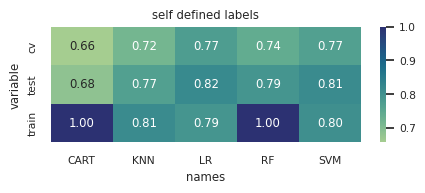

In [34]:
evals_nlp.plot_results()

<div style=" background-color:#3b3745;text-align:left; padding: 13px 13px; border-radius: 8px; color: white">
    
<ul>
    <li>We can note that the linear models <b>LR</b> and <b>SVM</b> generalise better compared to respective training data</li>
    <li>On the the other hand, we can note that <b>DT</b> and <b>RF</b> both seem to be overfitting (as the train/test difference is large)</li>
    <li>Its possible that errors made by the model are associated with our inexperience in correctly labelling sentiments, we should analyse the prediction results</li>
</ul>
</div>

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>ANALYSE RESULTS</span></b></p></div>

Let's check the test dataset, so we can see which rows gave us incorrect answers

In [35]:
all_test = evals_nlp.ly_test

# index of all misses
wrong_index = all_test[all_test['LR_test'] != all_test['perc_sent']].index
wrong_index = list(wrong_index)
show_panel(ldf.loc[wrong_index,:],50)

Tabulator(page_size=10, pagination='local', show_index=False, value=     ticker               ...)

Combine the prediction results with the input dataset

In [36]:
all_test.drop(['perc_sent'],axis=1,inplace=True)
pd.concat([ldf.loc[wrong_index,:],all_test.loc[wrong_index]],axis=1)

,ticker,headline,date,eventRet,perc_sent,LR_test,KNN_test,CART_test,SVM_test,RF_test
3071,GOOG,A few analysts shift targets after Alp...,2018-10-26,0.020697,0,1,0,1,1,1
60,NFLX,"Netflix (NFLX -3%) says it realized ""some peop...",2011-07-14,-0.014926,0,1,1,1,1,1
535,AMD,Intel looks like an attractive short at these ...,2012-07-10,-0.134708,0,1,1,1,1,1
2222,BA,"Boeing (NYSE:BA) has quickly lost ground, -1.9...",2017-05-10,-0.007669,0,1,0,1,1,1
169,AMZN,Gdgt's Ryan Block follows up on yesterday's Te...,2011-09-27,0.003368,0,1,1,1,1,1
2660,AMZN,Amazon’s (AMZN +2.1%) share gains toda...,2018-03-20,0.009894,0,1,1,1,1,1
293,NFLX,Netflix (NFLX -2.8%) shares slide after a repo...,2011-12-14,-0.056693,0,1,1,1,1,1
1754,AMZN,The organic grocery store sector is making som...,2015-12-10,-0.022229,1,0,0,0,0,0
493,AAPL,Is the Facebook IPO hurting Apple (AAPL -1.8%)...,2012-05-17,-0.042043,0,1,0,0,1,1
936,MSFT,Microsoft (NASDAQ:MSFT) isn't interested in No...,2013-06-12,-0.013170,0,1,1,0,1,1


### <b><span style='color:#CDE10F'>4.2 |</span> Generalised SL Models</b> 

Utilising **correctly labelled** data is very important:

- Let's train a more generalised model, which is trained on a number of tick news headlines (more than 12)
- Let's load data which was labelled by an **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">expert</mark>**, the dataset is quite a little bit larger (9470 entries)

In [37]:
# read input data
labelled_data = pd.read_csv('/kaggle/input/news-trading/newsdata_labelled_v3.csv',encoding = "ISO-8859-1")
labelled_data

,datetime,headline,ticker,sentiment
0,1/16/2020 5:25,$MMM fell on hard times but could be set to re...,MMM,0
1,1/11/2020 6:43,Wolfe Research Upgrades 3M $MMM to ¡§Peer Perf...,MMM,1
2,1/9/2020 9:37,3M $MMM Upgraded to ¡§Peer Perform¡¨ by Wolfe ...,MMM,1
3,1/8/2020 17:01,$MMM #insideday follow up as it also opened up...,MMM,1
4,1/8/2020 7:44,$MMM is best #dividend #stock out there and do...,MMM,0
...,...,...,...,...
9465,4/11/2019 1:24,$WMT - Walmart shifts to remodeling vs. new st...,WMT,1
9466,4/10/2019 6:05,Walmart INC $WMT Holder Texas Permanent School...,WMT,0
9467,4/9/2019 4:38,$WMT $GILD:3 Dividend Stocks Perfect for Retir...,WMT,1
9468,4/9/2019 4:30,Walmart expanding use of #robots to scan shelv...,WMT,1


In [38]:
# instantiate new evalation class
evals_nlp = nlp_evals(df=labelled_data,   # define the corpus dataframe
                      corpus='headline', # define which column contains the corpus
                      label='sentiment',
                      title='expert labels') # define the column which contains the label

evals_nlp.tts()

# spot check the algorithms
models = []
models.append(('LR', LogisticRegression()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('SVM', SVC()))
models.append(('RF', RandomForestClassifier()))

evals_nlp.define_models(models)
evals_nlp.kfold()

(9470, 96)
embeddings loaded!
train/test split!
models set!
model, cv mean, cv std, train, test
LR: 0.732841 (0.004658) 0.741640 0.725449
[[240 108]
 [152 447]]
KNN: 0.752201 (0.005395) 0.849818 0.732841
[[263 124]
 [129 431]]
CART: 0.639682 (0.011372) 0.999883 0.635692
[[231 184]
 [161 371]]
SVM: 0.782236 (0.003753) 0.823771 0.783527
[[259  72]
 [133 483]]
RF: 0.759239 (0.009294) 0.999883 0.751848
[[225  68]
 [167 487]]
evaluation finished!


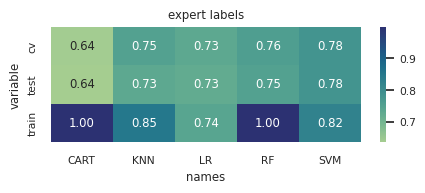

In [39]:
evals_nlp.plot_results()

<div style=" background-color:#3b3745;text-align:left; padding: 13px 13px; border-radius: 8px; color: white">
    
<ul>
    <li>As we can see our models do quite well compared to an expertly labelled dataset</li>
    <li>We can note that the difference between training and test sets is slightly larger than in our dataset</li>
    <li>Perhaps we should investigate whether <b>embedding dimension</b> is a critical factor which can inprove our model</li>
</ul>
</div>

### <b><span style='color:#CDE10F'> 4.3 |</span> SL Models w/ Increased Embedding Dimensions </b>

**<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">Embeddings</mark>** can encode various content of different quality:

- A lot of emphasis is generally placed on embedding quality (when for example we generate our own)
- `en_core_web_sm` contains only 96 embedding dimensions, the larger version `en_core_web_lg` has 300
- Let's investigate & see if we can improve our models on both **self labelled** & **expert labelled datasets**

In [40]:
# instantiate new evalation class
evals_nlp = nlp_evals(df=ldf,   # define the corpus dataframe
                      corpus='headline', # define which column contains the corpus
                      label='perc_sent',  # define the column which contains the label
                      spacy_model = 'en_core_web_lg') 


evals_nlp.tts()

# spot check the algorithms
models = []
models.append(('LR', LogisticRegression()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('SVM', SVC()))
models.append(('RF', RandomForestClassifier()))

evals_nlp.define_models(models)
evals_nlp.kfold()

(2146, 300)
embeddings loaded!
train/test split!
models set!
model, cv mean, cv std, train, test
LR: 0.733817 (0.007377) 0.834801 0.739535
[[ 16  23]
 [ 33 143]]
KNN: 0.696528 (0.020600) 0.799586 0.693023
[[ 12  29]
 [ 37 137]]
CART: 0.643696 (0.024111) 1.000000 0.655814
[[ 16  41]
 [ 33 125]]
SVM: 0.719323 (0.008758) 0.720870 0.772093
[[  0   0]
 [ 49 166]]
RF: 0.717245 (0.006927) 1.000000 0.748837
[[  4   9]
 [ 45 157]]
evaluation finished!


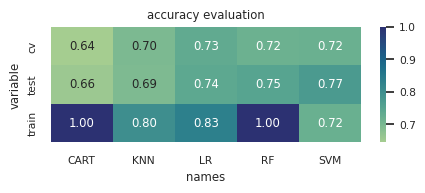

In [41]:
evals_nlp.plot_results()

<div style=" background-color:#3b3745;text-align:left; padding: 13px 13px; border-radius: 8px; color: white">
    
<ul>
    <li>We can see some general improvments for the linear model <b>LR</b> (performed a slightly better on the <b>test</b> set), however the <b>cross validation</b> scores didn't improve</li>
    <li>Perhaps the model can't really utilise the better quality embedding data on this smaller dataset, or perhaps the labelling quality is not very accurate</li>
</ul>
</div>

In [42]:
# instantiate new evalation class
evals_nlp = nlp_evals(df=labelled_data,   # define the corpus dataframe
                      corpus='headline', # define which column contains the corpus
                      label='sentiment',  # define the column which contains the label
                      spacy_model = 'en_core_web_lg') 


evals_nlp.tts()

# spot check the algorithms
models = []
models.append(('LR', LogisticRegression()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('SVM', SVC()))
models.append(('RF', RandomForestClassifier()))

evals_nlp.define_models(models)
evals_nlp.kfold()

(9470, 300)
embeddings loaded!
train/test split!
models set!
model, cv mean, cv std, train, test
LR: 0.871642 (0.003123) 0.896281 0.869060
[[330  62]
 [ 62 493]]
KNN: 0.763934 (0.011891) 0.852399 0.786695
[[289  99]
 [103 456]]
CART: 0.685323 (0.009705) 0.999883 0.687434
[[249 153]
 [143 402]]
SVM: 0.837382 (0.004240) 0.872463 0.836325
[[306  69]
 [ 86 486]]
RF: 0.790685 (0.005442) 0.999883 0.805702
[[275  67]
 [117 488]]
evaluation finished!


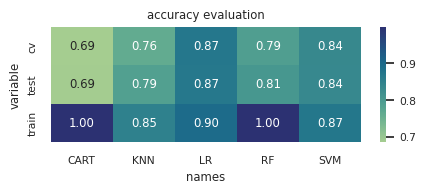

In [43]:
evals_nlp.plot_results()

<div style=" background-color:#3b3745;text-align:left; padding: 13px 13px; border-radius: 8px; color: white">
    
<ul>
    <li>Much more promising, we can note general improvments for most models (<b>LR</b>,<b>RF</b>, <b>SVM</b> & <b>KNN</b>)</li>
    <li>Such improvements imply that we should try something more sophisticated as well (ie. neural network)</li>

</ul>
</div>

### <b><span style='color:#CDE10F'> 4.4 |</span> DL Models w/ Increased Embedding Dimensions </b>

- It seems like we have some leeway for improving our model, we have quite a relatively large dataset & it is labelled by an expert
- **Embedding** seem to be the key to a good model, let's try a deep learning approach, which utilises an `embedding layer`

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>OUR DEEP LEARNING MODEL</span></b></p></div>

- We will utilise a **vocabulary size** of 20000
- limit the **maximum document length** to 50 words when **padding**
- Our model will use an **LSTM** layer as well as an **Embedding** layer
- The embedding layer will utilise a trainable **100 dimension embedding layer**
- For the binary classification problem, we a **binary_crossentropy** loss function & **adam** optimiser
- The deep learning model is trained on a **training set** and evaluated on a **test set** (90/10)
- The wrapper is then used to split the training data into a further **training** and **validation subset** (60/40)


In [44]:
from keras.wrappers.scikit_learn import KerasClassifier
import warnings; warnings.filterwarnings('ignore')

class nlp_evals_keras:
    
    def __init__(self,
                 df,
                 corpus,
                 label,
                 title='accuracy evaluation'
                ):
        
        self.df = deepcopy(df)
        self.corpus = corpus
        self.label = label
        self.title = title
    
    # split corpus into training and test subsets
                
    def tts(self,ratio=0.1):
        
        # split out validation dataset for the end
        Y = self.df[self.label]
        X = self.paddings

        X_train, X_test, y_train, y_test = train_test_split(X, Y, 
                                                            test_size=ratio, 
                                                            random_state=32)
        
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train 
        self.y_test = y_test
        print('train/test split!')
        
    # create tokeniser, vocabulary, generate numeric represention & pad all text
        
    def get_paddings(self):
        
        ### Create sequence
        vocabulary_size = 20000
        self.tokenizer = Tokenizer(num_words= vocabulary_size)
        self.tokenizer.fit_on_texts(self.df[self.corpus])
        sequences = self.tokenizer.texts_to_sequences(self.df[self.corpus])
        self.paddings = pad_sequences(sequences, maxlen=50)
        
    # train test evaluation

    def eval_tts(self):

        def create_model(input_length=50):
            model = Sequential()
            model.add(Embedding(20000, 100, input_length=50))
            model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
            model.add(Dense(1, activation='sigmoid'))
            model.compile(loss='binary_crossentropy', 
                          optimizer='adam', 
                          metrics=['accuracy'])    
            return model  

        clf = KerasClassifier(build_fn=create_model, 
                                     epochs=10, 
                                     verbose=1, 
                                     validation_split=0.4)

        clf.fit(self.X_train, self.y_train)

        ytrain_res = clf.predict(self.X_train)
        ytest_res = clf.predict(self.X_test)
        self.clf = clf # save model
        
        lstm_train_res = accuracy_score(ytrain_res,self.y_train)
        lstm_test_res = accuracy_score(ytest_res,self.y_test)
        print(lstm_train_res,lstm_test_res)

        self.y_train.to_frame()['lstm_res'] = ytrain_res
        self.y_test.to_frame()['lstm_res'] = ytest_res

    # inference on new corpus  
        
    def inference(self,df,corpus:str):
        sequences = self.tokenizer.texts_to_sequences(df[corpus])
        paddings = pad_sequences(sequences, maxlen=50)
        y_pred = self.clf.predict(paddings)
        df['lstm'] = y_pred
        return df

In [45]:
evals_nlp = nlp_evals_keras(df=labelled_data,   # define the corpus dataframe
                            corpus='headline', # define which column contains the corpus
                            label='sentiment')  # define the column which contains the label

evals_nlp.get_paddings() # prepare padded numeric data
evals_nlp.tts()     # split data into training and test subsets
evals_nlp.eval_tts() # train test split evaluation

train/test split!
Epoch 1/10
160/160 [==============================] - 17s 82ms/step - loss: 0.3655 - accuracy: 0.8173 - val_loss: 0.1201 - val_accuracy: 0.9601
Epoch 2/10
160/160 [==============================] - 13s 82ms/step - loss: 0.0579 - accuracy: 0.9834 - val_loss: 0.0921 - val_accuracy: 0.9718
Epoch 3/10
160/160 [==============================] - 13s 79ms/step - loss: 0.0182 - accuracy: 0.9951 - val_loss: 0.0897 - val_accuracy: 0.9724
Epoch 4/10
160/160 [==============================] - 13s 78ms/step - loss: 0.0079 - accuracy: 0.9975 - val_loss: 0.1040 - val_accuracy: 0.9704
Epoch 5/10
160/160 [==============================] - 13s 82ms/step - loss: 0.0056 - accuracy: 0.9984 - val_loss: 0.1199 - val_accuracy: 0.9686
Epoch 6/10
160/160 [==============================] - 13s 79ms/step - loss: 0.0041 - accuracy: 0.9992 - val_loss: 0.1163 - val_accuracy: 0.9701
Epoch 7/10
160/160 [==============================] - 13s 82ms/step - loss: 0.0026 - accuracy: 0.9992 - val_loss: 0.16

<div style=" background-color:#3b3745;text-align:left; padding: 13px 13px; border-radius: 8px; color: white">
    
<ul>
    <li>Very promising results, our <b>LSTM</b> based <b><span style='color:#CDE10F'>deep learning model</span></b> is able to achieve a validation accuracy of <b>0.97</b></li>
    <li>Let's make sure to save our embedding data as well and try to utilise it with faster ML models</li>
    <li>Now let's utilise the <b><span style='color:#CDE10F'>inference</span></b> method to create sentiment labels for our dataset, based on the deep learning model we just built
</ul>
</div>

In [46]:
ldf = evals_nlp.inference(ldf,'headline')
ldf.head()

68/68 [==============================] - 1s 12ms/step


,ticker,headline,date,eventRet,perc_sent,lstm
0,AMZN,Whole Foods (WFMI) -5.2% following a downgrade...,2011-05-02,0.031269,0,1
1,NFLX,Netflix (NFLX +1.1%) shares post early gains a...,2011-05-02,0.012173,1,1
2,MSFT,The likely winners in Microsoft's (MSFT -1.4%)...,2011-05-10,-0.007741,1,1
3,MSFT,Microsoft (MSFT -1.2%) and Skype signed their ...,2011-05-10,-0.007741,0,1
5,AMZN,Amazon.com (AMZN -1.7%) shares slip as comment...,2011-05-12,0.010426,0,1


### <b><span style='color:#CDE10F'> 4.5 |</span> VADER sentiment </b>

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>CONFIGURING THE LEXICON</span></b></p></div>


Next, lets turn our attention to **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">VADER</mark>**, unsupervised learning technique (which is **rule based**) used for text sentiment evaluation


Let's also define what is a **lexicon**, as we'll need to update ours for <b><span style='color:#CDE10F'>financial related text data</span></b>
- **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">Lexicons</mark>** are vocabulary dictionaries of sentiment values for different parts of a sentence
- They are generated using various techniques such as word position, its surrounding words, context & parts of speech (POS)
- All these parts are assigned a sentiment & we aggregate them all, in order to get a final score for each sentence
- We'll be utilising the NLTK vader module, which has its own lexicon, not tailored toward financial related tasks, so we'll need to update it!
- We'll be utilising a lexicon from the following source **[oliveira et al](https://www.sciencedirect.com/science/article/abs/pii/S0167923616300240)**

In [47]:
!ls /kaggle/input/news-trading/

combined.csv	   lexicon_sentiment.csv     return_data.csv
headlines.csv	   newsdata_labelled_v2.csv  sent_label_added_corpus.csv
headlines_archive  newsdata_labelled_v3.csv


In [48]:
import pandas as pd
lexicon = pd.read_csv('/kaggle/input/news-trading/lexicon_sentiment.csv')

In [49]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

def set_analyser(lex,df,corpus):

    # Prepare VADER sentiment analyzer
    
    sia = SentimentIntensityAnalyzer()
    lex['sentiment'] = (lex['Aff_Score'] + lex['Neg_Score'])/2 
    lex = dict(zip(lex.Item, lex.sentiment)) 
    lex = {k:v for k,v in lex.items() if len(k.split(' '))==1} 

    slex = {}
    for k, v in lex.items(): 
        if v > 0: 
            slex[k] = v / max(lex.values()) * 4
        else:
            slex[k] = v / min(lex.values()) * -4

    flex = {} 
    flex.update(slex) 
    flex.update(sia.lexicon) 
    sia.lexicon = flex
    
    # Evaluate sentiments
    
    sentiments = np.array([sia.polarity_scores(s)['compound'] for s in df[corpus]])
    
    return sia,sentiments

In [50]:
analyser,sentiments = set_analyser(lexicon,ldf,'headline')

In [51]:
ldf['vader_sent'] = sentiments
ldf.head()

,ticker,headline,date,eventRet,perc_sent,lstm,vader_sent
0,AMZN,Whole Foods (WFMI) -5.2% following a downgrade...,2011-05-02,0.031269,0,1,0.2115
1,NFLX,Netflix (NFLX +1.1%) shares post early gains a...,2011-05-02,0.012173,1,1,0.8575
2,MSFT,The likely winners in Microsoft's (MSFT -1.4%)...,2011-05-10,-0.007741,1,1,0.6971
3,MSFT,Microsoft (MSFT -1.2%) and Skype signed their ...,2011-05-10,-0.007741,0,1,0.7751
5,AMZN,Amazon.com (AMZN -1.7%) shares slip as comment...,2011-05-12,0.010426,0,1,-0.0413


In [52]:
# ldf.to_csv('sent_label_added_corpus.csv',index=False)

In [53]:
!ls /kaggle/input/news-trading/

combined.csv	   lexicon_sentiment.csv     return_data.csv
headlines.csv	   newsdata_labelled_v2.csv  sent_label_added_corpus.csv
headlines_archive  newsdata_labelled_v3.csv


In [54]:
import pandas as pd
ldf = pd.read_csv('/kaggle/input/news-trading/sent_label_added_corpus.csv')

<div style="color:white;display:fill;border-radius:8px;font-size:100%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#CDE10F'>SENTIMENT VS EVENT RETURN</span></b></p></div>

- Let's look at the relation between **sentiment polarity** and the **event return** for our updated **VADER** lexicon sentiment approach
- And correlation as well for all our approaches used (**textblob**, **deep learning** & **VADER**) approaches

In [55]:
import plotly.express as px

fig = px.scatter(ldf,x='vader_sent',y='eventRet',
                 facet_col='ticker',facet_col_wrap=3,
                 template='plotly_white',
                 width=None,height=1000,
                 title='event return & vader sentiment scatter plot')
fig.update_traces(marker=dict(size=4,
                              line=dict(width=1,
                                        color='DarkSlateGrey')),
                  opacity=0.3,
                  selector=dict(mode='markers'))

fig.show(renderer='iframe')

In [56]:
ldf.corr()

ldf.corr().style\
    .bar(align='mid',
         color=['#15C3BA','#CDE10F'])

,eventRet,perc_sent,lstm,vader_sent
eventRet,1.000000,0.320358,0.142312,0.251072
perc_sent,0.320358,1.000000,0.126808,0.164059
lstm,0.142312,0.126808,1.000000,0.221835
vader_sent,0.251072,0.164059,0.221835,1.000000


<div style=" background-color:#3b3745;text-align:left; padding: 13px 13px; border-radius: 8px; color: white">
    
<ul>
    <li>Interesting to note that both <b><span style='color:#CDE10F'>textblop</span></b> and <b><span style='color:#CDE10F'>VADER</span></b> approaches have quite a high postive correlation to event return</li>
<li>The supervised learning approach we used has a slightly lower correlation to event return</li>
</ul>
</div>

In [57]:
show_panel(ldf)

Tabulator(page_size=10, pagination='local', show_index=False, value=   ticker                 ...)

# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;background-color:#FFFFFF;overflow:hidden;background-color:#CDE10F"><b><span style='color:#FFFFFF'>5 |</span></b> <b>CONCLUDING REMARKS </b></div>

Lets summarise what we have done:
- In **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">Section 1</mark>**, we introduced thhe problem, outlining that one of the key components that can be useful in stock price prediction are <b><span style='color:#CDE10F'>news sources</span></b>
- In **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">Section 2</mark>**, we loaded <b><span style='color:#CDE10F'>financial market</span></b> data, parsed RSS <b><span style='color:#CDE10F'>news headlines</span></b> and defined the <b><span style='color:#CDE10F'>event return</span></b>
- In **<mark style="background-color:#CDE10F;color:white;border-radius:5px;opacity:0.9">Section 3</mark>**, we focused on creating sentiment values for our headline data (corpus), we looked at three different approaches:

 - **Textblob**, which is a Naive bayes based sentiment model pretrained on movie review data
 - We also tried **machine learning** approaches, for which we had to create labels. We used **textblob** sentiments, together with manual labeling bases on percentage and hit/miss labelling and to establish a basine. We also compared our results to **expert labelled** sentiments data of similar news headline data
 - Overall, the models we labelled performed better with lower number of embedding dimensions, more simpler linear models tended to performed better tree based models
 - As we used embedding pr higher dimension, the self labelled model showed worse results, however on the expertly labelled dataser, results we improving.
 - Thus we tried a neural network approach and found that it performs almost perfectly, both on training, validation and test datasets
 - This underlined the importance of correctly labelling data, which is best left to experts (if possible)
 - Lastly we tried **VADER**, which like **textblob** is pretrained on non financial related corpuses, so we utilised a customly labelled lexicon, which was made for financial related applications for sentiment evaluation